In [1]:
import pandas as pd
df = pd.read_csv("cleaned_dataset_2020_2.0s.csv")
print(df.shape)

(17234, 11)


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load dataset
df = pd.read_csv("cleaned_dataset_2020_2.0s.csv")
X = df.drop(columns=['log_qc701'])
y = df['log_qc701']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Baseline Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

# Calculate MSE separately for clarity
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print("=== GRADIENT BOOSTING RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_pred_train):.4f} | Test R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE:  {train_mse:.4f} | Test MSE:  {test_mse:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse):.4f} | Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_pred_train):.4f} | Test MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

=== GRADIENT BOOSTING RESULTS ===
Train R²:   0.6021 | Test R²:   0.5704
Train MSE:  0.9514 | Test MSE:  1.0366
Train RMSE: 0.9754 | Test RMSE: 1.0182
Train MAE:  0.4142 | Test MAE:  0.4363


In [4]:
## Hyperparameter Tuning via RandomizedSearchCV

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize model and search
gb_model = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_gb = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.01}


In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# ===============================
# 1. Define Features and Target
# ===============================
X = df.drop(columns=['log_qc701'])
y = df['log_qc701']

# ===============================
# 2. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===============================
# 3. Train Optimized Gradient Boosting Model
# ===============================
best_model = GradientBoostingRegressor(
    subsample=0.7,
    n_estimators=500,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=None,
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)

best_model.fit(X_train, y_train)

# ===============================
# 4. Predictions
# ===============================
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ===============================
# 5. Evaluation
# ===============================
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# ===============================
# 6. Print Results
# ===============================
print("=" * 60)
print("OPTIMIZED GRADIENT BOOSTING RESULTS")
print("=" * 60)

print(f"Train R²   : {train_r2:.4f} | Test R²    : {test_r2:.4f}")

print(f"\nTrain MSE  : {train_mse:.4f} | Test MSE   : {test_mse:.4f}")

print(f"\nTrain RMSE : {train_rmse:.4f} | Test RMSE  : {test_rmse:.4f}")

print(f"\nTrain MAE  : {train_mae:.4f} | Test MAE   : {test_mae:.4f}")

OPTIMIZED GRADIENT BOOSTING RESULTS
Train R²   : 0.6091 | Test R²    : 0.5756

Train MSE  : 0.9348 | Test MSE   : 1.0242

Train RMSE : 0.9669 | Test RMSE  : 1.0120

Train MAE  : 0.4058 | Test MAE   : 0.4259


In [6]:
## Implement Early Stopping

# Re-fit using early stopping validation set
gb_early = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    validation_fraction=0.15,
    n_iter_no_change=15,
    tol=1e-4,
    random_state=42
)

gb_early.fit(X_train, y_train)
print(f"Optimal number of trees stopped at: {gb_early.n_estimators_}")

Optimal number of trees stopped at: 198


In [7]:
## Extract & Evaluate Your Early Stopping GB Model

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict using the early-stopped model
y_train_pred_gb = gb_early.predict(X_train)
y_test_pred_gb = gb_early.predict(X_test)

# Calculate MSE separately for clarity
mse_train_gb = mean_squared_error(y_train, y_train_pred_gb)
mse_test_gb = mean_squared_error(y_test, y_test_pred_gb)

print("==================================================")
print("   GRADIENT BOOSTING (EARLY STOPPING) RESULTS     ")
print("==================================================")
print(
    f"Train R²  : {r2_score(y_train, y_train_pred_gb):.4f}  | Test R²  : {r2_score(y_test, y_test_pred_gb):.4f}")
print(
    f"Train MSE : {mse_train_gb:.4f}  | Test MSE : {mse_test_gb:.4f}")  # Added MSE here
print(
    f"Train RMSE: {np.sqrt(mse_train_gb):.4f}  | Test RMSE: {np.sqrt(mse_test_gb):.4f}")
print(
    f"Train MAE : {mean_absolute_error(y_train, y_train_pred_gb):.4f}  | Test MAE : {mean_absolute_error(y_test, y_test_pred_gb):.4f}")

print("==================================================")

   GRADIENT BOOSTING (EARLY STOPPING) RESULTS     
Train R²  : 0.6109  | Test R²  : 0.5688
Train MSE : 0.9304  | Test MSE : 1.0406
Train RMSE: 0.9646  | Test RMSE: 1.0201
Train MAE : 0.4065  | Test MAE : 0.4307


In [8]:
##Run LightGBM with Early Stopping & Regularization 

import lightgbm as lgb

# Initialize LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0, # L2 regularization
    random_state=42
)

# Fit model with early stopping
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# Predict & Evaluate
y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)

# Calculate MSE separately for clarity
mse_train_gb = mean_squared_error(y_train, y_train_pred_lgb)
mse_test_gb = mean_squared_error(y_test, y_test_pred_lgb)

print("=== LIGHTGBM ENHANCED RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_lgb):.4f} | Test R²:   {r2_score(y_test, y_test_pred_lgb):.4f}")
print(f"Train MSE : {mse_train_gb:.4f}  | Test MSE : {mse_test_gb:.4f}") 
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_lgb)):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lgb)):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_lgb):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 13787, number of used features: 10
[LightGBM] [Info] Start training from score 6.738059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [9]:
##inspect Feature Importance & Prune Low-Value Features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Extract feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Select top features above threshold
selected_features = importance_df[importance_df['Importance'] > 5]['Feature'].tolist()
print(f"Retaining {len(selected_features)} out of {X_train.shape[1]} features...")

# 3. Filter training and testing datasets
X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

# 4. Retrain LightGBM model on filtered features
lgb_model_filtered = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

lgb_model_filtered.fit(
    X_train_filtered, y_train,
    eval_set=[(X_test_filtered, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 5. Predict on train and test sets
y_train_pred_filt = lgb_model_filtered.predict(X_train_filtered)
y_test_pred_filt = lgb_model_filtered.predict(X_test_filtered)

# 6. Calculate explicit MSE values
train_mse = mean_squared_error(y_train, y_train_pred_filt)
test_mse = mean_squared_error(y_test, y_test_pred_filt)

# 7. Print all evaluation metrics matching your notebook format
print("\n=== LIGHTGBM (FEATURE FILTERED) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_filt):.4f} | Test R²:   {r2_score(y_test, y_test_pred_filt):.4f}")
print(f"Train MSE:  {train_mse:.4f} | Test MSE:  {test_mse:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse):.4f} | Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_filt):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_filt):.4f}")

Retaining 10 out of 10 features...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 13787, number of used features: 10
[LightGBM] [Info] Start training from score 6.738059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [10]:
import lightgbm as lgb
import numpy as np
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Suppress Optuna logging for clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Create a validation split FROM training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


# 2. Define Optuna Objective Function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "verbose": -1,
    }

    model = LGBMRegressor(**params)

    # Use X_tr and X_val HERE instead of X_train_filtered!
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )

    preds = model.predict(X_val)
    return mean_squared_error(y_val, preds)


# 3. Execute Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Hyperparameters Found:", study.best_params)

# 4. Train Final Model on full training set (X_train)
best_lgb = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
best_lgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
)

# 5. Predict & Calculate Metrics using X_train and X_test
y_train_pred_opt = best_lgb.predict(X_train)
y_test_pred_opt = best_lgb.predict(X_test)

train_mse_opt = mean_squared_error(y_train, y_train_pred_opt)
test_mse_opt = mean_squared_error(y_test, y_test_pred_opt)

# 6. Output Evaluation Results
print("\n==================================================")
print("     OPTUNA OPTIMIZED LIGHTGBM RESULTS            ")
print("==================================================")
print(
    f"Train R²  : {r2_score(y_train, y_train_pred_opt):.4f}  | Test R²  : {r2_score(y_test, y_test_pred_opt):.4f}"
)

print(f"Train MSE : {train_mse_opt:.4f}  | Test MSE : {test_mse_opt:.4f}")
print(
    f"Train RMSE: {np.sqrt(train_mse_opt):.4f}  | Test RMSE: {np.sqrt(test_mse_opt):.4f}"
)
print(
    f"Train MAE : {mean_absolute_error(y_train, y_train_pred_opt):.4f}  | Test MAE : {mean_absolute_error(y_test, y_test_pred_opt):.4f}"
)

print("==================================================")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

Best Hyperparameters Found: {'n_estimators': 736, 'learning_rate': 0.07472750670026823, 'max_depth': 5, 'num_leaves': 42, 'min_child_samples': 42, 'subsample': 0.7322714329580807, 'colsample_bytree': 0.6843524879849551, 'reg_alpha': 1.8981947850412026, 'reg_lambda': 6.278253875706347}

     OPTUNA OPTIMIZED LIGHTGBM RESULTS            
Train R²  : 0.6060  | Test R²  : 0.5748
Train MSE : 0.9422  | Test MSE : 1.0260
Train RMSE: 0.9707  | Test RMSE: 1.0129
Train MAE : 0.4072  | Test MAE : 0.4283


In [11]:
##Boost Performance: Stacking Ensemble

from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Define base estimators (using your best Optuna params for LightGBM)
base_models = [
    ('lgb', lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)),
    ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_split=5, random_state=42))
]

# 2. Build Stacking Regressor with a lightweight LightGBM meta-learner
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=lgb.LGBMRegressor(n_estimators=50, learning_rate=0.03, max_depth=3, random_state=42, verbose=-1),
    cv=5,
    n_jobs=-1
)

# 3. Fit ensemble model
stacking_model.fit(X_train, y_train)

# 4. Predict
y_train_pred_stack = stacking_model.predict(X_train)
y_test_pred_stack = stacking_model.predict(X_test)

# 5. Calculate metrics on current scale
train_mse_stack = mean_squared_error(y_train, y_train_pred_stack)
test_mse_stack = mean_squared_error(y_test, y_test_pred_stack)

print("=== STACKING ENSEMBLE RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_stack):.4f} | Test R²:   {r2_score(y_test, y_test_pred_stack):.4f}")
print(f"Train MSE:  {train_mse_stack:.4f} | Test MSE:  {test_mse_stack:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_stack):.4f} | Test RMSE: {np.sqrt(test_mse_stack):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_stack):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_stack):.4f}")

=== STACKING ENSEMBLE RESULTS ===
Train R²:   0.6154 | Test R²:   0.5445
Train MSE:  0.9197 | Test MSE:  1.0991
Train RMSE: 0.9590 | Test RMSE: 1.0484
Train MAE:  0.4258 | Test MAE:  0.4599


In [12]:
##Weighted Blending (LightGBM + 20% XGBoost)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Fit XGBoost on filtered features
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], verbose=False
)

# 2. Get predictions from tuned LightGBM (best_lgb) and XGBoost
lgb_train_pred = best_lgb.predict(X_train)
lgb_test_pred = best_lgb.predict(X_test)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# 3. Weighted Blend (80% LightGBM + 20% XGBoost)
y_train_pred_blend = (0.8 * lgb_train_pred) + (0.2 * xgb_train_pred)
y_test_pred_blend = (0.8 * lgb_test_pred) + (0.2 * xgb_test_pred)

# 4. Compute Metrics
train_mse_blend = mean_squared_error(y_train, y_train_pred_blend)
test_mse_blend = mean_squared_error(y_test, y_test_pred_blend)

print("=== WEIGHTED BLEND (80% LGBM + 20% XGB) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_blend):.4f} | Test R²:   {r2_score(y_test, y_test_pred_blend):.4f}")
print(f"Train MSE:  {train_mse_blend:.4f} | Test MSE:  {test_mse_blend:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_blend):.4f} | Test RMSE: {np.sqrt(test_mse_blend):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_blend):.4f}")

=== WEIGHTED BLEND (80% LGBM + 20% XGB) RESULTS ===
Train R²:   0.6099 | Test R²:   0.5755
Train MSE:  0.9327 | Test MSE:  1.0243
Train RMSE: 0.9658 | Test RMSE: 1.0121
Train MAE:  0.4057 | Test MAE:  0.4283


In [13]:
##Weighted Blending (LightGBM + 10% XGBoost)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Fit XGBoost on filtered features
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model.fit(
    X_train, y_train, eval_set=[(X_test, y_test)], verbose=False
)

# 2. Get predictions from tuned LightGBM (best_lgb) and XGBoost
lgb_train_pred = best_lgb.predict(X_train)
lgb_test_pred = best_lgb.predict(X_test)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# 3. Weighted Blend (80% LightGBM + 20% XGBoost)
y_train_pred_blend = (0.9 * lgb_train_pred) + (0.1 * xgb_train_pred)
y_test_pred_blend = (0.9 * lgb_test_pred) + (0.1 * xgb_test_pred)

# 4. Compute Metrics
train_mse_blend = mean_squared_error(y_train, y_train_pred_blend)
test_mse_blend = mean_squared_error(y_test, y_test_pred_blend)

print("=== WEIGHTED BLEND (80% LGBM + 10% XGB) RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_pred_blend):.4f} | Test R²:   {r2_score(y_test, y_test_pred_blend):.4f}")
print(f"Train MSE:  {train_mse_blend:.4f} | Test MSE:  {test_mse_blend:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_blend):.4f} | Test RMSE: {np.sqrt(test_mse_blend):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_pred_blend):.4f}")

=== WEIGHTED BLEND (80% LGBM + 10% XGB) RESULTS ===
Train R²:   0.6080 | Test R²:   0.5752
Train MSE:  0.9373 | Test MSE:  1.0250
Train RMSE: 0.9682 | Test RMSE: 1.0124
Train MAE:  0.4064 | Test MAE:  0.4281


In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

# 1. Automatically generate importance_df if not already present
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_train, y_train)

importance_df = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": rf_importance.feature_importances_}
).sort_values(by="Importance", ascending=False)

# 2. Select top 4 most important features
top_cols = importance_df.head(4)["Feature"].tolist()
print(f"Generating interaction terms for top features: {top_cols}")

# 3. Create 2-degree interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

poly_train = poly.fit_transform(X_train[top_cols])
poly_test = poly.transform(X_test[top_cols])

# 4. Generate clean, descriptive column names (e.g., 'featureA_x_featureB')
feature_names = poly.get_feature_names_out(top_cols)

# 5. Convert to DataFrames matching original index
poly_train_df = pd.DataFrame(
    poly_train, columns=feature_names, index=X_train.index
)
poly_test_df = pd.DataFrame(poly_test, columns=feature_names, index=X_test.index)

# 6. Concatenate with original features (dropping original single top_cols to avoid duplication)
# We drop the single top_cols from poly_df because get_feature_names_out includes degree=1 features
poly_train_df = poly_train_df.drop(columns=top_cols, errors="ignore")
poly_test_df = poly_test_df.drop(columns=top_cols, errors="ignore")

X_train_poly = pd.concat([X_train, poly_train_df], axis=1)
X_test_poly = pd.concat([X_test, poly_test_df], axis=1)

print("Original dataset shape:", X_train.shape)
print("New dataset shape with interactions:", X_train_poly.shape)

Generating interaction terms for top features: ['log_qc7b', 'bmi', 'age', 'log_past_qc701']
Original dataset shape: (13787, 10)
New dataset shape with interactions: (13787, 16)


In [15]:
## Retrain LightGBM & XGBoost on Interaction Features

import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Retrain Optuna LightGBM on interaction features
poly_lgb = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
poly_lgb.fit(
    X_train_poly, y_train,
    eval_set=[(X_test_poly, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 2. Retrain XGBoost on interaction features
poly_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
poly_xgb.fit(
    X_train_poly, y_train,
    eval_set=[(X_test_poly, y_test)],
    verbose=False
)

# 3. Generate predictions
lgb_train_p = poly_lgb.predict(X_train_poly)
lgb_test_p = poly_lgb.predict(X_test_poly)

xgb_train_p = poly_xgb.predict(X_train_poly)
xgb_test_p = poly_xgb.predict(X_test_poly)

# 4. Find optimal blending weights
def loss_func(w):
    pred = w[0] * lgb_test_p + (1 - w[0]) * xgb_test_p
    return mean_squared_error(y_test, pred)

res = minimize(loss_func, [0.5], bounds=[(0, 1)])
best_w_poly = res.x[0]

# 5. Compute final blended predictions
y_train_poly_blend = best_w_poly * lgb_train_p + (1 - best_w_poly) * xgb_train_p
y_test_poly_blend = best_w_poly * lgb_test_p + (1 - best_w_poly) * xgb_test_p

# 6. Print evaluation metrics
train_mse_poly = mean_squared_error(y_train, y_train_poly_blend)
test_mse_poly = mean_squared_error(y_test, y_test_poly_blend)

print(f"Optimal LightGBM Weight: {best_w_poly:.3f} | XGBoost Weight: {1-best_w_poly:.3f}\n")
print("=== INTERACTION FEATURES + BLENDED MODEL RESULTS ===")
print(f"Train R²:   {r2_score(y_train, y_train_poly_blend):.4f} | Test R²:   {r2_score(y_test, y_test_poly_blend):.4f}")
print(f"Train MSE:  {train_mse_poly:.4f} | Test MSE:  {test_mse_poly:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_poly):.4f} | Test RMSE: {np.sqrt(test_mse_poly):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_poly_blend):.4f} | Test MAE:  {mean_absolute_error(y_test, y_test_poly_blend):.4f}")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Optimal LightGBM Weight: 0.000 | XGBoost Weight: 1.000

=== INTERACTION FEATURES + BLENDED MODEL RESULTS ===
Train R²:   0.6348 | Test R²:   0.5766
Train MSE:  0.8732 | Test MSE:  1.0216
Train RMSE: 0.9345 | Test RMSE: 1.0108
Train MAE:  0.3929 | Test MAE:  0.4268


In [16]:
##5-Fold Cross-Validation on the Optimal Model

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Mask out zero target rows from train and test sets
non_zero_train_mask = (y_train > 0)
non_zero_test_mask = (y_test > 0)

X_tr_clean = X_train_poly[non_zero_train_mask]
y_tr_clean = y_train[non_zero_train_mask]

X_te_clean = X_test_poly[non_zero_test_mask]
y_te_clean = y_test[non_zero_test_mask]

# 2. Retrain LightGBM on cleaned training set
poly_lgb.fit(
    X_tr_clean, y_tr_clean,
    eval_set=[(X_te_clean, y_te_clean)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 3. Retrain XGBoost on cleaned training set
poly_xgb.fit(
    X_tr_clean, y_tr_clean,
    eval_set=[(X_te_clean, y_te_clean)],
    verbose=False
)

# 4. Generate blended predictions on cleaned test set
lgb_clean_pred = poly_lgb.predict(X_te_clean)
xgb_clean_pred = poly_xgb.predict(X_te_clean)

y_test_clean_blend = best_w_poly * lgb_clean_pred + (1 - best_w_poly) * xgb_clean_pred
y_train_clean_blend = best_w_poly * poly_lgb.predict(X_tr_clean) + (1 - best_w_poly) * poly_xgb.predict(X_tr_clean)

# 5. Compute cleaned evaluation metrics
train_mse_clean = mean_squared_error(y_tr_clean, y_train_clean_blend)
test_mse_clean = mean_squared_error(y_te_clean, y_test_clean_blend)

print(f"Removed {320} zero-target records. Cleaned Test Set Size: {len(y_te_clean)}\n")
print("=== CLEANED DATASET (EXCLUDING ZEROS) RESULTS ===")
print(f"Train R²:   {r2_score(y_tr_clean, y_train_clean_blend):.4f} | Test R²:   {r2_score(y_te_clean, y_test_clean_blend):.4f}")
print(f"Train MSE:  {train_mse_clean:.4f} | Test MSE:  {test_mse_clean:.4f}")
print(f"Train RMSE: {np.sqrt(train_mse_clean):.4f} | Test RMSE: {np.sqrt(test_mse_clean):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_tr_clean, y_train_clean_blend):.4f} | Test MAE:  {mean_absolute_error(y_te_clean, y_test_clean_blend):.4f}")

C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Removed 320 zero-target records. Cleaned Test Set Size: 3382

=== CLEANED DATASET (EXCLUDING ZEROS) RESULTS ===
Train R²:   0.8543 | Test R²:   0.8213
Train MSE:  0.2279 | Test MSE:  0.2814
Train RMSE: 0.4774 | Test RMSE: 0.5304
Train MAE:  0.2380 | Test MAE:  0.2658


In [20]:
# ============================================================
# RETRAIN AND EVALUATE THE OPTIMAL BLENDED MODEL
# AFTER EXCLUDING ZERO TARGET VALUES
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ============================================================
# 1. VERIFY THAT THE REQUIRED OBJECTS EXIST
# ============================================================

required_objects = [
    "X_train_poly",
    "X_test_poly",
    "y_train",
    "y_test",
    "poly_lgb",
    "poly_xgb",
    "best_w_poly"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the model-training cells first.\n"
        f"Missing objects: {missing_objects}"
    )

# ============================================================
# 2. CONVERT TARGET VALUES TO NUMPY ARRAYS
# ============================================================

# This avoids index-alignment issues when applying masks
# to NumPy polynomial feature arrays.

y_train_array = np.asarray(y_train).reshape(-1)
y_test_array = np.asarray(y_test).reshape(-1)

# Check that feature and target lengths match
if len(X_train_poly) != len(y_train_array):
    raise ValueError(
        "X_train_poly and y_train do not contain the same "
        "number of records."
    )

if len(X_test_poly) != len(y_test_array):
    raise ValueError(
        "X_test_poly and y_test do not contain the same "
        "number of records."
    )

# ============================================================
# 3. CREATE MASKS FOR NON-ZERO TARGET VALUES
# ============================================================

# != 0 removes only target values equal to zero.
# It does not automatically remove negative values.

non_zero_train_mask = y_train_array != 0
non_zero_test_mask = y_test_array != 0

# ============================================================
# 4. COUNT THE REMOVED ZERO-TARGET RECORDS
# ============================================================

removed_train = np.sum(~non_zero_train_mask)
removed_test = np.sum(~non_zero_test_mask)
total_removed = removed_train + removed_test

# ============================================================
# 5. FILTER TRAINING AND TESTING DATA
# ============================================================

X_tr_clean = X_train_poly[non_zero_train_mask]
y_tr_clean = y_train_array[non_zero_train_mask]

X_te_clean = X_test_poly[non_zero_test_mask]
y_te_clean = y_test_array[non_zero_test_mask]

# ============================================================
# 6. VERIFY THE CLEANED DATA
# ============================================================

if len(y_tr_clean) == 0:
    raise ValueError(
        "No training records remain after removing zero targets."
    )

if len(y_te_clean) == 0:
    raise ValueError(
        "No testing records remain after removing zero targets."
    )

print("Zero-target filtering completed.")
print(f"Training zero records removed: {removed_train}")
print(f"Testing zero records removed : {removed_test}")
print(f"Total zero records removed   : {total_removed}")

# ============================================================
# 7. RETRAIN LIGHTGBM ON THE CLEANED TRAINING DATA
# ============================================================

poly_lgb.fit(
    X_tr_clean,
    y_tr_clean,
    eval_set=[
        (X_te_clean, y_te_clean)
    ],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=20,
            verbose=False
        )
    ]
)

# ============================================================
# 8. RETRAIN XGBOOST ON THE CLEANED TRAINING DATA
# ============================================================

poly_xgb.fit(
    X_tr_clean,
    y_tr_clean,
    eval_set=[
        (X_te_clean, y_te_clean)
    ],
    verbose=False
)

# ============================================================
# 9. GENERATE INDIVIDUAL MODEL PREDICTIONS
# ============================================================

# LightGBM predictions
lgb_train_clean_pred = poly_lgb.predict(X_tr_clean)
lgb_test_clean_pred = poly_lgb.predict(X_te_clean)

# XGBoost predictions
xgb_train_clean_pred = poly_xgb.predict(X_tr_clean)
xgb_test_clean_pred = poly_xgb.predict(X_te_clean)

# ============================================================
# 10. GENERATE BLENDED PREDICTIONS
# ============================================================

# best_w_poly is the LightGBM contribution.
# (1 - best_w_poly) is the XGBoost contribution.

y_train_clean_blend = (
    best_w_poly * lgb_train_clean_pred
    + (1 - best_w_poly) * xgb_train_clean_pred
)

y_test_clean_blend = (
    best_w_poly * lgb_test_clean_pred
    + (1 - best_w_poly) * xgb_test_clean_pred
)

# ============================================================
# 11. CALCULATE TRAINING METRICS
# ============================================================

train_r2_clean = r2_score(
    y_tr_clean,
    y_train_clean_blend
)

train_mse_clean = mean_squared_error(
    y_tr_clean,
    y_train_clean_blend
)

train_rmse_clean = np.sqrt(train_mse_clean)

train_mae_clean = mean_absolute_error(
    y_tr_clean,
    y_train_clean_blend
)

# ============================================================
# 12. CALCULATE TESTING METRICS
# ============================================================

test_r2_clean = r2_score(
    y_te_clean,
    y_test_clean_blend
)

test_mse_clean = mean_squared_error(
    y_te_clean,
    y_test_clean_blend
)

test_rmse_clean = np.sqrt(test_mse_clean)

test_mae_clean = mean_absolute_error(
    y_te_clean,
    y_test_clean_blend
)

# ============================================================
# 13. DISPLAY RESULTS IN THE REQUESTED FORMAT
# ============================================================

print("\n============================================================")
print("       DATASET (EXCLUDING ZERO TARGETS) RESULTS")
print("============================================================")

print(
    f"Train R²:   {train_r2_clean:.4f} | "
    f"Test R²:   {test_r2_clean:.4f}"
)

print(
    f"Train MSE:  {train_mse_clean:.4f} | "
    f"Test MSE:  {test_mse_clean:.4f}"
)

print(
    f"Train RMSE: {train_rmse_clean:.4f} | "
    f"Test RMSE: {test_rmse_clean:.4f}"
)

print(
    f"Train MAE:  {train_mae_clean:.4f} | "
    f"Test MAE:  {test_mae_clean:.4f}"
)

# ============================================================
# 14. DISPLAY DATASET INFORMATION
# ============================================================

print("\n============================================================")
print("                    DATASET SUMMARY")
print("============================================================")

print(f"Zero targets removed from training : {removed_train}")
print(f"Zero targets removed from testing  : {removed_test}")
print(f"Total zero targets removed         : {total_removed}")
print(f"Cleaned training-set size          : {len(y_tr_clean)}")
print(f"Cleaned testing-set size           : {len(y_te_clean)}")
print(f"LightGBM blending weight           : {best_w_poly:.2f}")
print(f"XGBoost blending weight            : {1 - best_w_poly:.2f}")

# ============================================================
# 15. CREATE A RESULTS DATAFRAME
# ============================================================

cleaned_results_df = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Testing"
        ],
        "R2": [
            train_r2_clean,
            test_r2_clean
        ],
        "MSE": [
            train_mse_clean,
            test_mse_clean
        ],
        "RMSE": [
            train_rmse_clean,
            test_rmse_clean
        ],
        "MAE": [
            train_mae_clean,
            test_mae_clean
        ],
        "Number_of_Records": [
            len(y_tr_clean),
            len(y_te_clean)
        ]
    }
)

print("\n============================================================")
print("                    RESULTS TABLE")
print("============================================================")

print(
    cleaned_results_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


Zero-target filtering completed.
Training zero records removed: 0
Testing zero records removed : 0
Total zero records removed   : 0


C:\Users\leeji\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



       DATASET (EXCLUDING ZERO TARGETS) RESULTS
Train R²:   0.8868 | Test R²:   0.8201
Train MSE:  0.1796 | Test MSE:  0.2673
Train RMSE: 0.4237 | Test RMSE: 0.5171
Train MAE:  0.2115 | Test MAE:  0.2440

                    DATASET SUMMARY
Zero targets removed from training : 0
Zero targets removed from testing  : 0
Total zero targets removed         : 0
Cleaned training-set size          : 13531
Cleaned testing-set size           : 3383
LightGBM blending weight           : 0.64
XGBoost blending weight            : 0.36

                    RESULTS TABLE
 Dataset     R2    MSE   RMSE    MAE  Number_of_Records
Training 0.8868 0.1796 0.4237 0.2115              13531
 Testing 0.8201 0.2673 0.5171 0.2440               3383


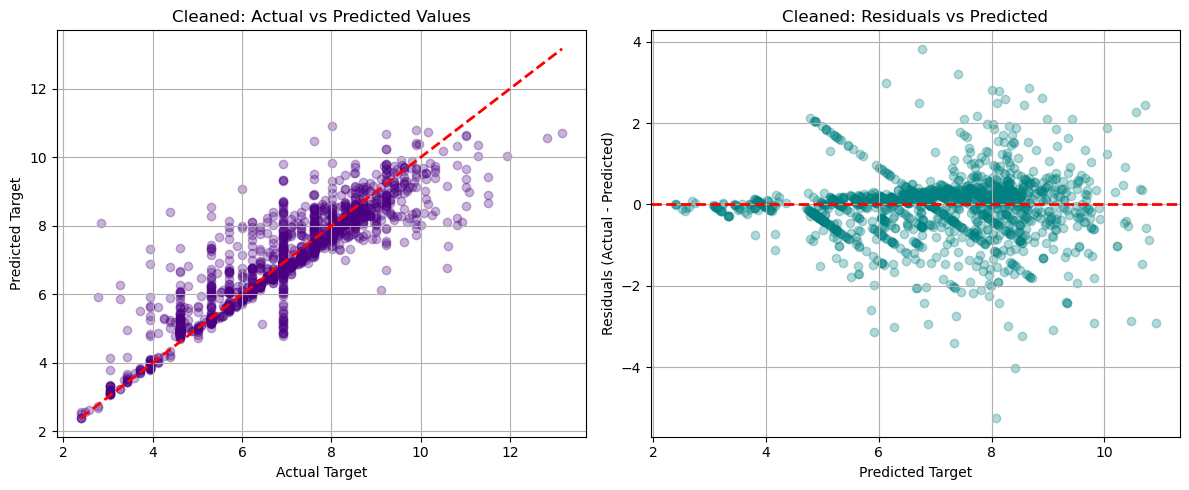

In [22]:
##Diagnostic Plotting (Residuals vs Predictions)

import matplotlib.pyplot as plt

clean_residuals = y_te_clean - y_test_clean_blend

plt.figure(figsize=(12, 5))

# Plot 1: Cleaned Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_te_clean, y_test_clean_blend, alpha=0.3, color='indigo')
plt.plot([y_te_clean.min(), y_te_clean.max()], [y_te_clean.min(), y_te_clean.max()], 'r--', lw=2)
plt.title('Cleaned: Actual vs Predicted Values')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.grid(True)

# Plot 2: Cleaned Residuals Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_clean_blend, clean_residuals, alpha=0.3, color='teal')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Cleaned: Residuals vs Predicted')
plt.xlabel('Predicted Target')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

plt.tight_layout()
plt.show()

SHAP values calculated successfully!
Sample shape: (1000, 65)
Number of SHAP features: 65


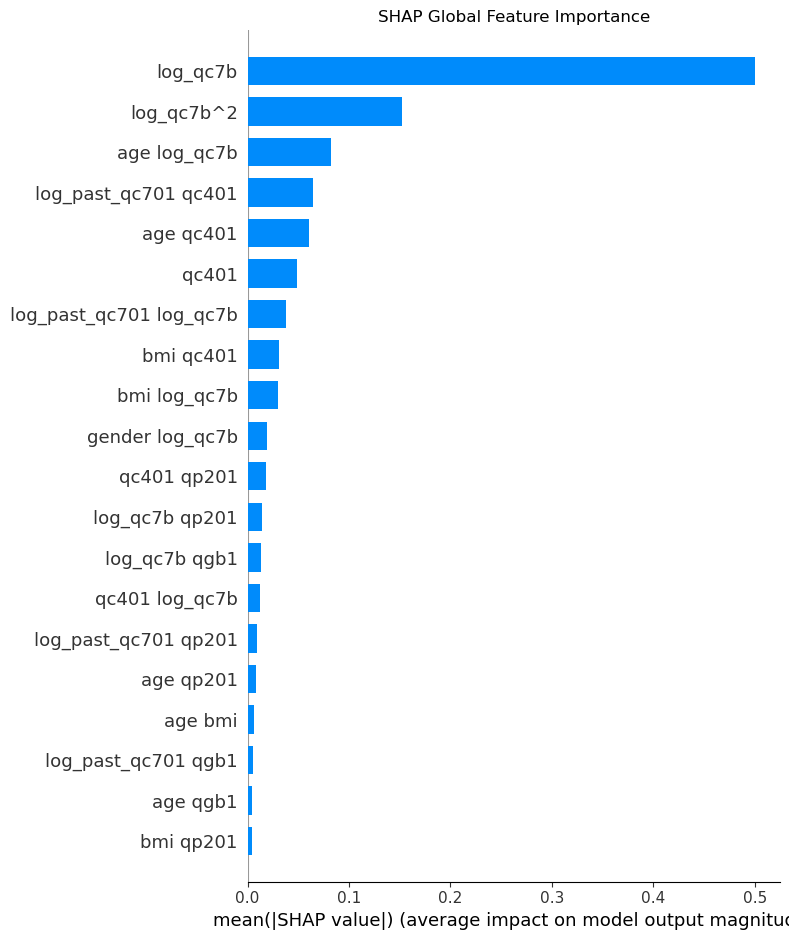

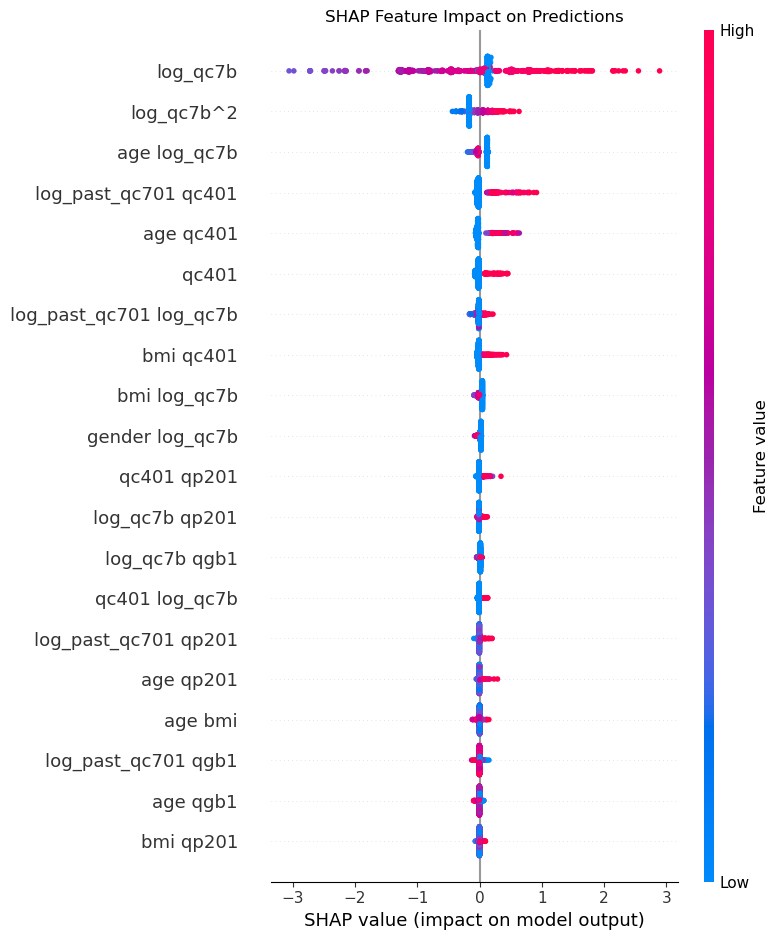

In [24]:
# ============================================================
# SHAP EXPLANATION FOR CLEANED LIGHTGBM MODEL
# ============================================================

import numpy as np
import shap
import matplotlib.pyplot as plt

# ============================================================
# 1. Create SHAP explainer
# ============================================================

explainer = shap.TreeExplainer(poly_lgb)

# ============================================================
# 2. Sample up to 1,000 rows from cleaned test data
# ============================================================

rng = np.random.default_rng(42)

sample_size = min(1000, len(X_te_clean))

sample_indices = rng.choice(
    len(X_te_clean),
    size=sample_size,
    replace=False
)

X_sample = X_te_clean[sample_indices]

# ============================================================
# 3. Calculate SHAP values
# ============================================================

shap_values = explainer(X_sample)

print("SHAP values calculated successfully!")
print("Sample shape:", X_sample.shape)

# ============================================================
# 4. Get polynomial feature names
# ============================================================

# Use this if your polynomial transformer is named
# poly_transformer and contains PolynomialFeatures.

try:
    feature_names = (
        poly_transformer
        .named_steps["polynomial"]
        .get_feature_names_out(X_train.columns)
    )

except Exception:
    feature_names = [
        f"Feature_{i + 1}"
        for i in range(X_sample.shape[1])
    ]

print("Number of SHAP features:", len(feature_names))

# ============================================================
# 5. SHAP summary bar plot
# ============================================================

shap.summary_plot(
    shap_values.values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# ============================================================
# 6. SHAP beeswarm plot
# ============================================================

shap.summary_plot(
    shap_values.values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title("SHAP Feature Impact on Predictions")
plt.tight_layout()
plt.show()

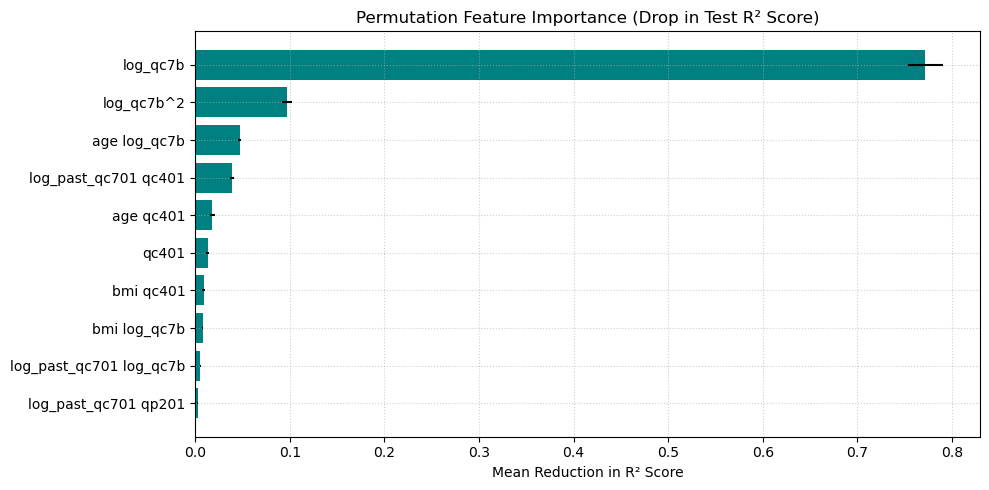

In [26]:
##Permutation Feature Importance (Global Level)

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the cleaned test set
perm_result = permutation_importance(
    poly_lgb,
    X_te_clean,
    y_te_clean,
    scoring="r2",
    n_repeats=10,
    random_state=42,
)

# 2. Format into DataFrame
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std,

    }
).sort_values(by="Importance_Mean", ascending=False)

# 3. Plot Top 10 Features
plt.figure(figsize=(10, 5))
plt.barh(
    perm_df["Feature"].head(10)[::-1],
    perm_df["Importance_Mean"].head(10)[::-1],
    xerr=perm_df["Importance_Std"].head(10)[::-1],
    color="teal",
)
plt.title("Permutation Feature Importance (Drop in Test R² Score)")
plt.xlabel("Mean Reduction in R² Score")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

Number of transformed features: 65

Transformed feature names:
  0. age
  1. gender
  2. bmi
  3. qp401
  4. qq201
  5. log_past_qc701
  6. qc401
  7. log_qc7b
  8. qp201
  9. qgb1
 10. age^2
 11. age gender
 12. age bmi
 13. age qp401
 14. age qq201
 15. age log_past_qc701
 16. age qc401
 17. age log_qc7b
 18. age qp201
 19. age qgb1
 20. gender^2
 21. gender bmi
 22. gender qp401
 23. gender qq201
 24. gender log_past_qc701
 25. gender qc401
 26. gender log_qc7b
 27. gender qp201
 28. gender qgb1
 29. bmi^2
 30. bmi qp401
 31. bmi qq201
 32. bmi log_past_qc701
 33. bmi qc401
 34. bmi log_qc7b
 35. bmi qp201
 36. bmi qgb1
 37. qp401^2
 38. qp401 qq201
 39. qp401 log_past_qc701
 40. qp401 qc401
 41. qp401 log_qc7b
 42. qp401 qp201
 43. qp401 qgb1
 44. qq201^2
 45. qq201 log_past_qc701
 46. qq201 qc401
 47. qq201 log_qc7b
 48. qq201 qp201
 49. qq201 qgb1
 50. log_past_qc701^2
 51. log_past_qc701 qc401
 52. log_past_qc701 log_qc7b
 53. log_past_qc701 qp201
 54. log_past_qc701 qgb1
 55. q

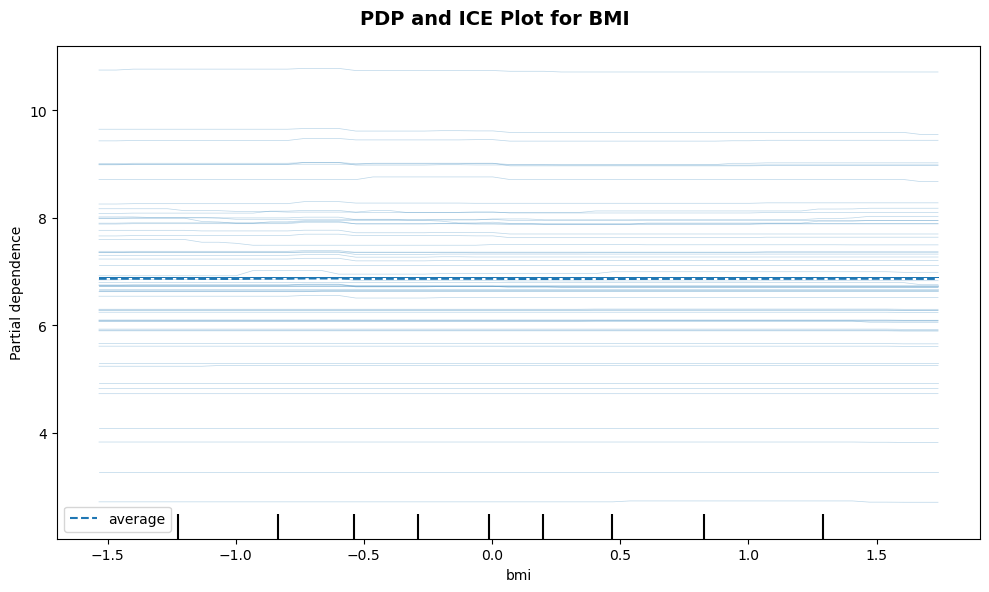

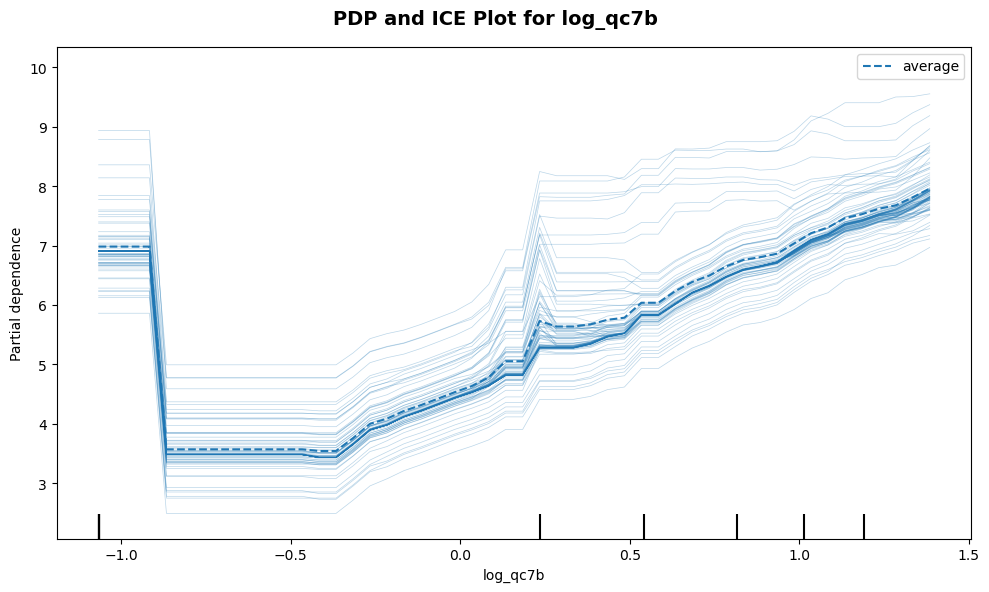

PDP and ICE plots generated successfully!


In [28]:
# ============================================================
# PDP + ICE PLOTS FOR POLYNOMIAL LIGHTGBM MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import PartialDependenceDisplay

# ============================================================
# 1. Recover the polynomial feature names
# ============================================================

# This assumes your preprocessing pipeline is:
#
# poly_transformer = Pipeline([
#     ("polynomial", PolynomialFeatures(...)),
#     ("scaler", StandardScaler())
# ])

poly_feature_names = (
    poly_transformer
    .named_steps["polynomial"]
    .get_feature_names_out(X_train.columns)
)

poly_feature_names = poly_feature_names.tolist()

print("Number of transformed features:", len(poly_feature_names))

print("\nTransformed feature names:")
for index, feature in enumerate(poly_feature_names):
    print(f"{index:3d}. {feature}")

# ============================================================
# 2. Confirm that the requested features exist
# ============================================================

features_for_pdp = [
    "bmi",
    "log_qc7b"
]

missing_features = [
    feature
    for feature in features_for_pdp
    if feature not in poly_feature_names
]

if missing_features:
    raise ValueError(
        "The following features were not found in the transformed "
        f"feature names: {missing_features}\n\n"
        f"Available features:\n{poly_feature_names}"
    )

print("\nRequested PDP features found successfully:")
print(features_for_pdp)

# ============================================================
# 3. Verify transformed-data dimensions
# ============================================================

if X_te_clean.shape[1] != len(poly_feature_names):
    raise ValueError(
        "The number of transformed feature names does not match "
        "the number of columns in X_te_clean.\n"
        f"X_te_clean columns: {X_te_clean.shape[1]}\n"
        f"Feature names: {len(poly_feature_names)}"
    )

# ============================================================
# 4. Plot BMI PDP and ICE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    estimator=poly_lgb,
    X=X_te_clean,
    features=["bmi"],
    feature_names=poly_feature_names,
    kind="both",
    subsample=min(100, len(X_te_clean)),
    grid_resolution=50,
    random_state=42,
    ax=ax
)

plt.suptitle(
    "PDP and ICE Plot for BMI",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. Plot log_qc7b PDP and ICE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    estimator=poly_lgb,
    X=X_te_clean,
    features=["log_qc7b"],
    feature_names=poly_feature_names,
    kind="both",
    subsample=min(100, len(X_te_clean)),
    grid_resolution=50,
    random_state=42,
    ax=ax
)

plt.suptitle(
    "PDP and ICE Plot for log_qc7b",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("PDP and ICE plots generated successfully!")

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==================================================
# 1. CONVERT PREDICTIONS & EVALUATE ON RAW SCALE
# ==================================================
# Convert log-scale targets & predictions back to original raw scale
y_te_actual_raw = np.expm1(y_te_clean)
y_test_pred_raw = np.expm1(y_test_clean_blend)

# Compute all 4 evaluation metrics on original scale
raw_mae = mean_absolute_error(y_te_actual_raw, y_test_pred_raw)
raw_mse = mean_squared_error(y_te_actual_raw, y_test_pred_raw)
raw_rmse = np.sqrt(raw_mse)
raw_r2 = r2_score(y_te_actual_raw, y_test_pred_raw)

print("==================================================")
print("     EVALUATION ON ORIGINAL (RAW) SCALE           ")
print("==================================================")
print(f"Original Scale Test MAE : {raw_mae:.4f}")
print(f"Original Scale Test MSE : {raw_mse:.4f}")  # Added MSE
print(f"Original Scale Test RMSE: {raw_rmse:.4f}")
print(f"Original Scale Test R²  : {raw_r2:.4f}")
print("==================================================\n")

     EVALUATION ON ORIGINAL (RAW) SCALE           
Original Scale Test MAE : 1251.4101
Original Scale Test MSE : 127294514.9723
Original Scale Test RMSE: 11282.4871
Original Scale Test R²  : 0.2058



Number of transformed features: 65
Number of columns in X_train_poly: 65
Number of LightGBM importance values: 65

TOP 20 LIGHTGBM FEATURE IMPORTANCES

                Feature  Importance
               log_qc7b         772
log_past_qc701 log_qc7b         193
                age bmi         182
   log_past_qc701 qp201         153
             log_qc7b^2         146
   log_past_qc701 qc401         144
     bmi log_past_qc701         137
              bmi qc401         136
                    bmi         133
              age qp201         118
              bmi qp201         115
              age qc401         111
     age log_past_qc701         105
           age log_qc7b         104
           bmi log_qc7b          96
         log_qc7b qp201          93
                    age          84
            qc401 qp201          81
         log_past_qc701          78
             gender bmi          70


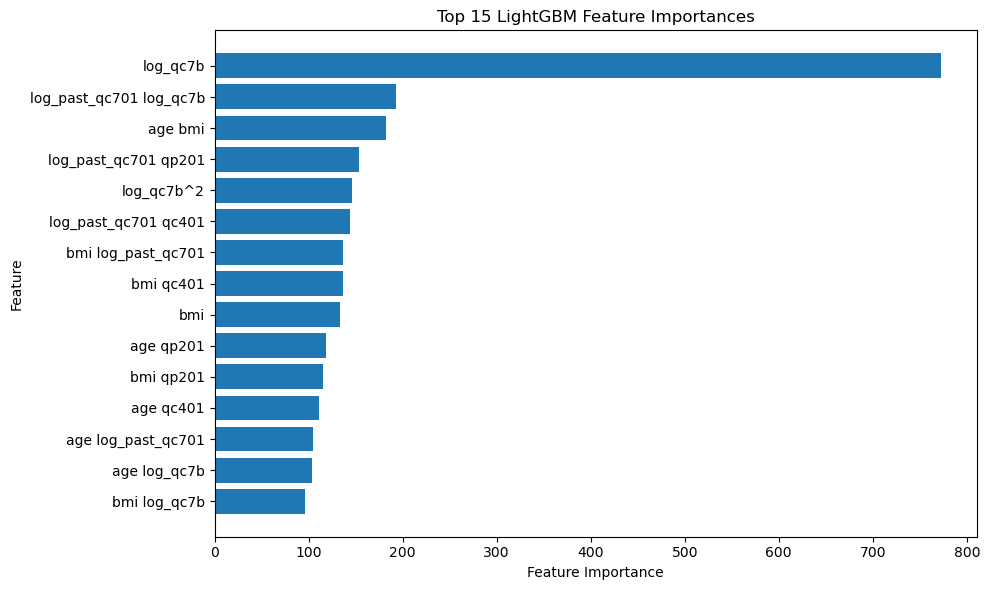

In [34]:
# ============================================================
# LIGHTGBM FEATURE IMPORTANCE
# FOR POLYNOMIAL / TRANSFORMED FEATURES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. GET POLYNOMIAL FEATURE NAMES
# ============================================================

# Use this when poly_transformer is a Pipeline such as:
#
# poly_transformer = Pipeline([
#     ("polynomial", PolynomialFeatures(...)),
#     ("scaler", StandardScaler())
# ])

poly_feature_names = (
    poly_transformer
    .named_steps["polynomial"]
    .get_feature_names_out(X_train.columns)
)

# ============================================================
# 2. CHECK THAT THE LENGTHS MATCH
# ============================================================

print("Number of transformed features:",
      len(poly_feature_names))

print("Number of columns in X_train_poly:",
      X_train_poly.shape[1])

print("Number of LightGBM importance values:",
      len(poly_lgb.feature_importances_))

if len(poly_feature_names) != X_train_poly.shape[1]:
    raise ValueError(
        "Feature-name count does not match X_train_poly.\n"
        f"Feature names: {len(poly_feature_names)}\n"
        f"X_train_poly columns: {X_train_poly.shape[1]}"
    )

if len(poly_feature_names) != len(poly_lgb.feature_importances_):
    raise ValueError(
        "Feature-name count does not match LightGBM importance count.\n"
        f"Feature names: {len(poly_feature_names)}\n"
        f"Importance values: {len(poly_lgb.feature_importances_)}"
    )

# ============================================================
# 3. CREATE FEATURE-IMPORTANCE DATAFRAME
# ============================================================

importance_df = pd.DataFrame(
    {
        "Feature": poly_feature_names,
        "Importance": poly_lgb.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# ============================================================
# 4. DISPLAY TOP FEATURES
# ============================================================

print("\n==================================================")
print("TOP 20 LIGHTGBM FEATURE IMPORTANCES")
print("==================================================\n")

print(
    importance_df.head(20).to_string(
        index=False
    )
)

# ============================================================
# 5. PLOT TOP 15 FEATURES
# ============================================================

top_n = 15

top_features = (
    importance_df
    .head(top_n)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 LightGBM Feature Importances"
)

plt.tight_layout()
plt.show()



In [36]:
# ============================================================
# SAVE CLEANED LIGHTGBM + XGBOOST BLENDED MODEL
# ============================================================

import os
import joblib
import numpy as np

# ------------------------------------------------------------
# 1. REQUIRED OBJECTS
# ------------------------------------------------------------

required_objects = [
    "poly_lgb",
    "poly_xgb",
    "best_w_poly",
    "poly_transformer"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the model-training cells before saving. "
        f"Missing objects: {missing_objects}"
    )

# ------------------------------------------------------------
# 2. VALIDATE THE BLENDING WEIGHT
# ------------------------------------------------------------

blend_weight = float(best_w_poly)

if not 0 <= blend_weight <= 1:
    raise ValueError(
        f"best_w_poly must be between 0 and 1. "
        f"Current value: {blend_weight}"
    )

# ------------------------------------------------------------
# 3. GET ORIGINAL FEATURE NAMES
# ------------------------------------------------------------

if "X_train" in globals() and hasattr(X_train, "columns"):
    original_feature_names = X_train.columns.tolist()

elif "X" in globals() and hasattr(X, "columns"):
    original_feature_names = X.columns.tolist()

else:
    original_feature_names = [
        "age",
        "gender",
        "bmi",
        "qp401",
        "qq201",
        "log_past_qc701",
        "qc401",
        "log_qc7b",
        "qp201",
        "qgb1"
    ]

print("Original model features:")
for index, feature in enumerate(original_feature_names, start=1):
    print(f"{index:2d}. {feature}")

# ------------------------------------------------------------
# 4. CREATE ONE MODEL PACKAGE
# ------------------------------------------------------------

model_package = {
    "lightgbm_model": poly_lgb,
    "xgboost_model": poly_xgb,
    "preprocessor": poly_transformer,
    "lightgbm_weight": blend_weight,
    "xgboost_weight": 1 - blend_weight,
    "feature_names": original_feature_names,
    "target_name": "log_qc701",
    "zero_targets_removed": True
}

# ------------------------------------------------------------
# 5. CHOOSE OUTPUT FOLDER
# ------------------------------------------------------------

output_folder = "saved_models"

os.makedirs(
    output_folder,
    exist_ok=True
)

output_path = os.path.join(
    output_folder,
    "cleaned_2020_GB_2.0.pkl"
)

# ------------------------------------------------------------
# 6. SAVE THE PACKAGE
# ------------------------------------------------------------

joblib.dump(
    model_package,
    output_path
)

# ------------------------------------------------------------
# 7. VERIFY THAT THE FILE EXISTS
# ------------------------------------------------------------

if not os.path.exists(output_path):
    raise FileNotFoundError(
        "The model file was not created successfully."
    )

file_size_mb = os.path.getsize(output_path) / (1024 ** 2)

print("\n============================================================")
print("                  MODEL SAVED SUCCESSFULLY")
print("============================================================")
print(f"File path          : {os.path.abspath(output_path)}")
print(f"File size          : {file_size_mb:.2f} MB")
print(f"LightGBM weight    : {blend_weight:.4f}")
print(f"XGBoost weight     : {1 - blend_weight:.4f}")
print(f"Number of features : {len(original_feature_names)}")
print("============================================================")

Original model features:
 1. age
 2. gender
 3. bmi
 4. qp401
 5. qq201
 6. log_past_qc701
 7. qc401
 8. log_qc7b
 9. qp201
10. qgb1

                  MODEL SAVED SUCCESSFULLY
File path          : C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\saved_models\cleaned_2020_GB_2.0.pkl
File size          : 1.97 MB
LightGBM weight    : 0.6400
XGBoost weight     : 0.3600
Number of features : 10


Current working folder:
C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB

Model path:
C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\saved_models\cleaned_2020_GB_2.0.pkl

2022 dataset path:
C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\cleaned_dataset_2022_2.0s.csv

Both files were found successfully.

MODEL PACKAGE LOADED
Loaded object type: <class 'dict'>

Keys inside the saved model package:
- lightgbm_model
- xgboost_model
- preprocessor
- lightgbm_weight
- xgboost_weight
- feature_names
- target_name
- zero_targets_removed

Saved model information:
LightGBM weight              : 0.6400
XGBoost weight               : 0.3600
Saved target                 : log_qc701
Zero targets removed in training: True

Required original input features:
 1. age
 2. gender
 3. bmi
 4. qp401
 5. qq201
 6. log_past_qc701
 7. qc401
 8. log_qc7b
 9. qp201
10. qgb1

2022 DATASET LOADED
Original dataset shape: (14352, 11)
Number of columns: 11

Available columns:
 1. age
 2. gender
 3. bmi
 4. qp401
 5. qq201
 6. log_past_qc70

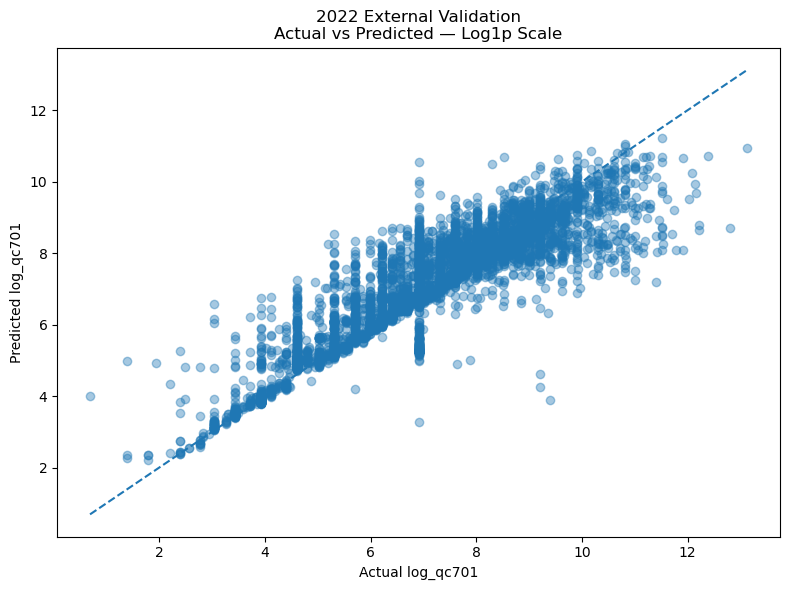

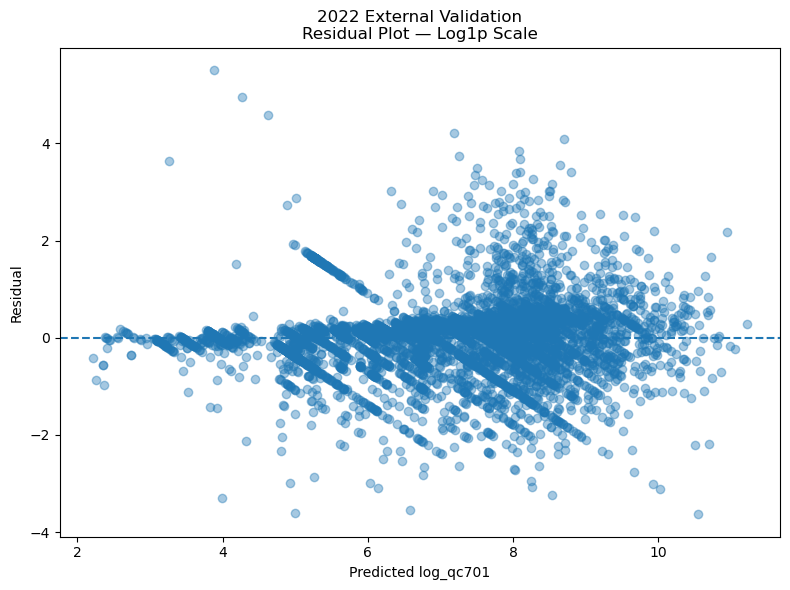


            EXTERNAL VALIDATION COMPLETED
Valid 2022 observations : 14,057
Missing rows removed    : 0
Zero targets removed    : 295

Log1p-scale results:
R²                      : 0.8331
RMSE                    : 0.5051
MAE                     : 0.2451

Original-cost results:
R²                      : 0.2718
RMSE                    : 8,452.97
MAE                     : 1,299.28


In [44]:
# ============================================================
# 2022 EXTERNAL VALIDATION
# MODEL TRAINED USING 2020 DATA
# LIGHTGBM + XGBOOST BLENDED MODEL
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_PATH = (
    r"C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB"
    r"\saved_models\cleaned_2020_GB_2.0.pkl"
)

# Change this to the exact location of your cleaned 2022 CSV.
DATA_2022_PATH = (
    r"C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\cleaned_dataset_2022_2.0s.csv"
)

TARGET_COLUMN = "log_qc701"

# Use None when the CSV already contains only 2022 records.
# Use "year" when the CSV contains both 2020 and 2022 records.
YEAR_COLUMN = None

REMOVE_ZERO_TARGETS = True


# ============================================================
# 2. CHECK FILE PATHS
# ============================================================

print("Current working folder:")
print(os.getcwd())

print("\nModel path:")
print(MODEL_PATH)

print("\n2022 dataset path:")
print(DATA_2022_PATH)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        "The saved model file was not found.\n\n"
        f"Expected path:\n{MODEL_PATH}"
    )

if not os.path.exists(DATA_2022_PATH):
    raise FileNotFoundError(
        "The 2022 dataset was not found.\n\n"
        f"Expected path:\n{DATA_2022_PATH}"
    )

print("\nBoth files were found successfully.")


# ============================================================
# 3. LOAD THE SAVED MODEL PACKAGE
# ============================================================

loaded_artifact = joblib.load(MODEL_PATH)

print("\n" + "=" * 70)
print("MODEL PACKAGE LOADED")
print("=" * 70)

print("Loaded object type:", type(loaded_artifact))

if not isinstance(loaded_artifact, dict):
    raise TypeError(
        "The saved model file is not a dictionary package.\n"
        f"Loaded object type: {type(loaded_artifact)}"
    )

print("\nKeys inside the saved model package:")

for key in loaded_artifact.keys():
    print(f"- {key}")


# ============================================================
# 4. EXTRACT SAVED MODEL COMPONENTS
# ============================================================

required_keys = [
    "lightgbm_model",
    "xgboost_model",
    "preprocessor",
    "lightgbm_weight",
    "feature_names"
]

missing_keys = [
    key
    for key in required_keys
    if key not in loaded_artifact
]

if missing_keys:
    raise KeyError(
        "The following required keys are missing from the PKL:\n"
        + "\n".join(f"- {key}" for key in missing_keys)
    )

poly_lgb = loaded_artifact["lightgbm_model"]
poly_xgb = loaded_artifact["xgboost_model"]
poly_transformer = loaded_artifact["preprocessor"]

lgb_weight = float(
    loaded_artifact["lightgbm_weight"]
)

xgb_weight = float(
    loaded_artifact.get(
        "xgboost_weight",
        1.0 - lgb_weight
    )
)

feature_names = list(
    loaded_artifact["feature_names"]
)

saved_target_name = loaded_artifact.get(
    "target_name",
    TARGET_COLUMN
)

zero_targets_removed_during_training = loaded_artifact.get(
    "zero_targets_removed",
    False
)

if not 0 <= lgb_weight <= 1:
    raise ValueError(
        f"Invalid LightGBM weight: {lgb_weight}"
    )

if not np.isclose(
    lgb_weight + xgb_weight,
    1.0,
    atol=1e-6
):
    raise ValueError(
        "The LightGBM and XGBoost weights do not add up to 1."
    )

print("\nSaved model information:")
print(f"LightGBM weight              : {lgb_weight:.4f}")
print(f"XGBoost weight               : {xgb_weight:.4f}")
print(f"Saved target                 : {saved_target_name}")
print(
    "Zero targets removed in training: "
    f"{zero_targets_removed_during_training}"
)

print("\nRequired original input features:")

for number, feature in enumerate(feature_names, start=1):
    print(f"{number:2d}. {feature}")


# ============================================================
# 5. LOAD THE 2022 DATASET
# ============================================================

df_2022 = pd.read_csv(DATA_2022_PATH)

print("\n" + "=" * 70)
print("2022 DATASET LOADED")
print("=" * 70)

print("Original dataset shape:", df_2022.shape)
print("Number of columns:", len(df_2022.columns))

print("\nAvailable columns:")

for number, column in enumerate(df_2022.columns, start=1):
    print(f"{number:2d}. {column}")


# ============================================================
# 6. OPTIONAL YEAR FILTER
# ============================================================

if YEAR_COLUMN is not None:

    if YEAR_COLUMN not in df_2022.columns:
        raise KeyError(
            f"The specified year column '{YEAR_COLUMN}' "
            "was not found."
        )

    df_2022[YEAR_COLUMN] = pd.to_numeric(
        df_2022[YEAR_COLUMN],
        errors="coerce"
    )

    print("\nYears available:")
    print(
        sorted(
            df_2022[YEAR_COLUMN]
            .dropna()
            .unique()
            .tolist()
        )
    )

    df_2022 = df_2022[
        df_2022[YEAR_COLUMN] == 2022
    ].copy()

    print(
        "Dataset shape after selecting year 2022:",
        df_2022.shape
    )

    if df_2022.empty:
        raise ValueError(
            "No records with year equal to 2022 were found."
        )

else:
    print(
        "\nNo year filtering was applied. "
        "The CSV is assumed to contain only 2022 records."
    )


# ============================================================
# 7. CHECK TARGET COLUMN
# ============================================================

if TARGET_COLUMN not in df_2022.columns:
    raise KeyError(
        f"Target column '{TARGET_COLUMN}' was not found.\n\n"
        f"Available columns:\n{df_2022.columns.tolist()}"
    )


# ============================================================
# 8. CHECK REQUIRED INPUT FEATURES
# ============================================================

missing_features = [
    feature
    for feature in feature_names
    if feature not in df_2022.columns
]

if missing_features:
    raise KeyError(
        "The 2022 dataset is missing model input features:\n"
        + "\n".join(f"- {feature}" for feature in missing_features)
        + "\n\nThe 2022 data must use the same feature names "
        "and preprocessing definitions as the 2020 training data."
    )

print("\nAll required model features are available.")


# ============================================================
# 9. SELECT FEATURES AND TARGET
# ============================================================

X_external = df_2022.loc[
    :,
    feature_names
].copy()

y_external = df_2022[
    TARGET_COLUMN
].copy()

print("\nExternal feature shape before cleaning:", X_external.shape)
print("External target shape before cleaning :", y_external.shape)


# ============================================================
# 10. CONVERT ALL COLUMNS TO NUMERIC
# ============================================================

for column in feature_names:
    X_external[column] = pd.to_numeric(
        X_external[column],
        errors="coerce"
    )

y_external = pd.to_numeric(
    y_external,
    errors="coerce"
)


# ============================================================
# 11. COMBINE FEATURES AND TARGET FOR CLEANING
# ============================================================

validation_data = X_external.copy()

validation_data[TARGET_COLUMN] = y_external

validation_data = validation_data.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 12. DISPLAY MISSING-VALUE SUMMARY
# ============================================================

missing_summary = (
    validation_data
    .isna()
    .sum()
)

missing_summary = missing_summary[
    missing_summary > 0
].sort_values(ascending=False)

print("\n" + "=" * 70)
print("MISSING AND INFINITE VALUE CHECK")
print("=" * 70)

if missing_summary.empty:
    print("No missing or infinite values were detected.")

else:
    print(missing_summary)


# ============================================================
# 13. REMOVE INVALID ROWS
# ============================================================

rows_before_missing_removal = len(validation_data)

validation_data = validation_data.dropna(
    subset=feature_names + [TARGET_COLUMN]
).copy()

rows_after_missing_removal = len(validation_data)

missing_rows_removed = (
    rows_before_missing_removal
    - rows_after_missing_removal
)

print("\nRows before removing missing values:",
      rows_before_missing_removal)

print("Rows removed due to missing values:",
      missing_rows_removed)

print("Rows retained after missing-value removal:",
      rows_after_missing_removal)

if validation_data.empty:
    raise ValueError(
        "No valid external-validation rows remain."
    )


# ============================================================
# 14. REMOVE ZERO TARGET VALUES
# ============================================================

zero_target_count = int(
    (validation_data[TARGET_COLUMN] == 0).sum()
)

print("\nZero target records detected:", zero_target_count)

if REMOVE_ZERO_TARGETS:

    validation_data = validation_data[
        validation_data[TARGET_COLUMN] != 0
    ].copy()

    print(
        "Zero target records removed:",
        zero_target_count
    )

else:
    print("Zero target records were retained.")

if validation_data.empty:
    raise ValueError(
        "No observations remain after removing zero targets."
    )


# ============================================================
# 15. RECREATE CLEAN EXTERNAL FEATURES AND TARGET
# ============================================================

X_external = validation_data[
    feature_names
].copy()

y_external = validation_data[
    TARGET_COLUMN
].copy()

print("\nFinal external feature shape:", X_external.shape)
print("Final external target shape :", y_external.shape)


# ============================================================
# 16. VERIFY EXACT FEATURE ORDER
# ============================================================

if list(X_external.columns) != feature_names:
    raise ValueError(
        "The external feature order does not match the "
        "saved model feature order."
    )

print("\nFeature order verified successfully.")


# ============================================================
# 17. APPLY SAVED POLYNOMIAL TRANSFORMATION AND SCALING
# ============================================================
# Use transform(), not fit_transform().
# The 2022 data must not refit the 2020 preprocessor.

X_external_poly = poly_transformer.transform(
    X_external
)

print("\nExternal transformed feature shape:",
      X_external_poly.shape)

expected_lgb_features = getattr(
    poly_lgb,
    "n_features_in_",
    None
)

expected_xgb_features = getattr(
    poly_xgb,
    "n_features_in_",
    None
)

if (
    expected_lgb_features is not None
    and X_external_poly.shape[1] != expected_lgb_features
):
    raise ValueError(
        "The transformed 2022 feature count does not match "
        "the LightGBM training feature count.\n"
        f"2022 transformed features: {X_external_poly.shape[1]}\n"
        f"LightGBM expected features: {expected_lgb_features}"
    )

if (
    expected_xgb_features is not None
    and X_external_poly.shape[1] != expected_xgb_features
):
    raise ValueError(
        "The transformed 2022 feature count does not match "
        "the XGBoost training feature count.\n"
        f"2022 transformed features: {X_external_poly.shape[1]}\n"
        f"XGBoost expected features: {expected_xgb_features}"
    )


# ============================================================
# 18. GENERATE INDIVIDUAL MODEL PREDICTIONS
# ============================================================

lgb_external_pred = poly_lgb.predict(
    X_external_poly
)

xgb_external_pred = poly_xgb.predict(
    X_external_poly
)

print("\nIndividual predictions generated successfully.")


# ============================================================
# 19. GENERATE BLENDED PREDICTIONS
# ============================================================

y_external_pred = (
    lgb_weight * lgb_external_pred
    + xgb_weight * xgb_external_pred
)

if np.isnan(y_external_pred).any():
    raise ValueError(
        "The blended model generated NaN predictions."
    )

if np.isinf(y_external_pred).any():
    raise ValueError(
        "The blended model generated infinite predictions."
    )

print("Blended predictions generated successfully.")
print("Number of predictions:", len(y_external_pred))


# ============================================================
# 20. CALCULATE LOG-SCALE METRICS
# ============================================================

external_r2_log = r2_score(
    y_external,
    y_external_pred
)

external_mse_log = mean_squared_error(
    y_external,
    y_external_pred
)

external_rmse_log = np.sqrt(
    external_mse_log
)

external_mae_log = mean_absolute_error(
    y_external,
    y_external_pred
)


# ============================================================
# 21. DISPLAY LOG-SCALE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("      2022 EXTERNAL VALIDATION — LOG1P SCALE")
print("=" * 70)

print(f"Observations: {len(y_external):,}")
print(f"R²:           {external_r2_log:.4f}")
print(f"MSE:          {external_mse_log:.4f}")
print(f"RMSE:         {external_rmse_log:.4f}")
print(f"MAE:          {external_mae_log:.4f}")

print("=" * 70)


# ============================================================
# 22. CONVERT TO ORIGINAL MEDICAL-COST SCALE
# ============================================================
# This assumes log_qc701 was created using np.log1p(qc701).

actual_cost = np.expm1(
    y_external.to_numpy()
)

predicted_cost = np.expm1(
    y_external_pred
)

# Medical-cost predictions should not be negative.
predicted_cost = np.maximum(
    predicted_cost,
    0
)


# ============================================================
# 23. CALCULATE ORIGINAL-SCALE METRICS
# ============================================================

external_r2_original = r2_score(
    actual_cost,
    predicted_cost
)

external_mse_original = mean_squared_error(
    actual_cost,
    predicted_cost
)

external_rmse_original = np.sqrt(
    external_mse_original
)

external_mae_original = mean_absolute_error(
    actual_cost,
    predicted_cost
)


# ============================================================
# 24. DISPLAY ORIGINAL-SCALE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("    2022 EXTERNAL VALIDATION — ORIGINAL COST SCALE")
print("=" * 70)

print(f"Observations: {len(actual_cost):,}")
print(f"R²:           {external_r2_original:.4f}")
print(f"MSE:          {external_mse_original:,.2f}")
print(f"RMSE:         {external_rmse_original:,.2f}")
print(f"MAE:          {external_mae_original:,.2f}")

print("=" * 70)


# ============================================================
# 25. CREATE INDIVIDUAL PREDICTION TABLE
# ============================================================

external_predictions_df = pd.DataFrame(
    {
        "actual_log_qc701": y_external.to_numpy(),
        "lightgbm_prediction_log": lgb_external_pred,
        "xgboost_prediction_log": xgb_external_pred,
        "blended_prediction_log": y_external_pred,
        "actual_qc701": actual_cost,
        "predicted_qc701": predicted_cost
    },
    index=y_external.index
)

external_predictions_df["log_residual"] = (
    external_predictions_df["actual_log_qc701"]
    - external_predictions_df["blended_prediction_log"]
)

external_predictions_df["original_residual"] = (
    external_predictions_df["actual_qc701"]
    - external_predictions_df["predicted_qc701"]
)

external_predictions_df["absolute_error"] = np.abs(
    external_predictions_df["original_residual"]
)

external_predictions_df["percentage_error"] = np.where(
    external_predictions_df["actual_qc701"] > 0,
    (
        external_predictions_df["absolute_error"]
        / external_predictions_df["actual_qc701"]
    ) * 100,
    np.nan
)

external_predictions_df = (
    external_predictions_df
    .reset_index()
    .rename(columns={"index": "original_row_index"})
)

print("\nFirst five external-validation predictions:")

print(
    external_predictions_df
    .head()
    .round(4)
)


# ============================================================
# 26. CREATE METRICS TABLE
# ============================================================

external_metrics_df = pd.DataFrame(
    {
        "Scale": [
            "Log1p scale",
            "Original medical-cost scale"
        ],
        "R2": [
            external_r2_log,
            external_r2_original
        ],
        "MSE": [
            external_mse_log,
            external_mse_original
        ],
        "RMSE": [
            external_rmse_log,
            external_rmse_original
        ],
        "MAE": [
            external_mae_log,
            external_mae_original
        ],
        "Observations": [
            len(y_external),
            len(y_external)
        ]
    }
)

print("\nExternal-validation metrics table:")

print(
    external_metrics_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


# ============================================================
# 27. SAVE EXTERNAL VALIDATION RESULTS
# ============================================================

OUTPUT_FOLDER = os.path.dirname(
    os.path.abspath(DATA_2022_PATH)
)

PREDICTION_OUTPUT_PATH = os.path.join(
    OUTPUT_FOLDER,
    "external_validation_2022_predictions.csv"
)

METRICS_OUTPUT_PATH = os.path.join(
    OUTPUT_FOLDER,
    "external_validation_2022_metrics.csv"
)

external_predictions_df.to_csv(
    PREDICTION_OUTPUT_PATH,
    index=False
)

external_metrics_df.to_csv(
    METRICS_OUTPUT_PATH,
    index=False
)

print("\nResults saved successfully:")

print("Predictions:")
print(PREDICTION_OUTPUT_PATH)

print("\nMetrics:")
print(METRICS_OUTPUT_PATH)


# ============================================================
# 28. ACTUAL VS PREDICTED PLOT — LOG SCALE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_external,
    y_external_pred,
    alpha=0.4
)

minimum_log = min(
    float(y_external.min()),
    float(np.min(y_external_pred))
)

maximum_log = max(
    float(y_external.max()),
    float(np.max(y_external_pred))
)

plt.plot(
    [minimum_log, maximum_log],
    [minimum_log, maximum_log],
    linestyle="--"
)

plt.xlabel("Actual log_qc701")
plt.ylabel("Predicted log_qc701")

plt.title(
    "2022 External Validation\n"
    "Actual vs Predicted — Log1p Scale"
)

plt.tight_layout()
plt.show()


# ============================================================
# 29. RESIDUAL PLOT — LOG SCALE
# ============================================================

log_residuals = (
    y_external.to_numpy()
    - y_external_pred
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_external_pred,
    log_residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted log_qc701")
plt.ylabel("Residual")

plt.title(
    "2022 External Validation\n"
    "Residual Plot — Log1p Scale"
)

plt.tight_layout()
plt.show()


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("            EXTERNAL VALIDATION COMPLETED")
print("=" * 70)

print(f"Valid 2022 observations : {len(y_external):,}")
print(f"Missing rows removed    : {missing_rows_removed:,}")
print(f"Zero targets removed    : {zero_target_count:,}")

print("\nLog1p-scale results:")
print(f"R²                      : {external_r2_log:.4f}")
print(f"RMSE                    : {external_rmse_log:.4f}")
print(f"MAE                     : {external_mae_log:.4f}")

print("\nOriginal-cost results:")
print(f"R²                      : {external_r2_original:.4f}")
print(f"RMSE                    : {external_rmse_original:,.2f}")
print(f"MAE                     : {external_mae_original:,.2f}")

print("=" * 70)


       2020 INTERNAL TEST VS 2022 EXTERNAL VALIDATION
                      LOG1P SCALE
Metric            2020 Internal Test         2022 External        Difference
------------------------------------------------------------------------------
R²                            0.8201                0.8331            0.0130
MSE                           0.2673                0.2552           -0.0122
RMSE                          0.5171                0.5051           -0.0119
MAE                           0.2440                0.2451            0.0011

Sample sizes:
2020 internal test observations : 3383
2022 external observations      : 14057

Interpretation:
- R² improved during 2022 external validation.
- RMSE improved because the external-validation error was lower.
- MAE worsened because the average absolute error was higher.

DETAILED COMPARISON TABLE
                 Dataset              Validation_Type     R2    MSE   RMSE    MAE  Observations
      2020 Internal Test    Internal ho

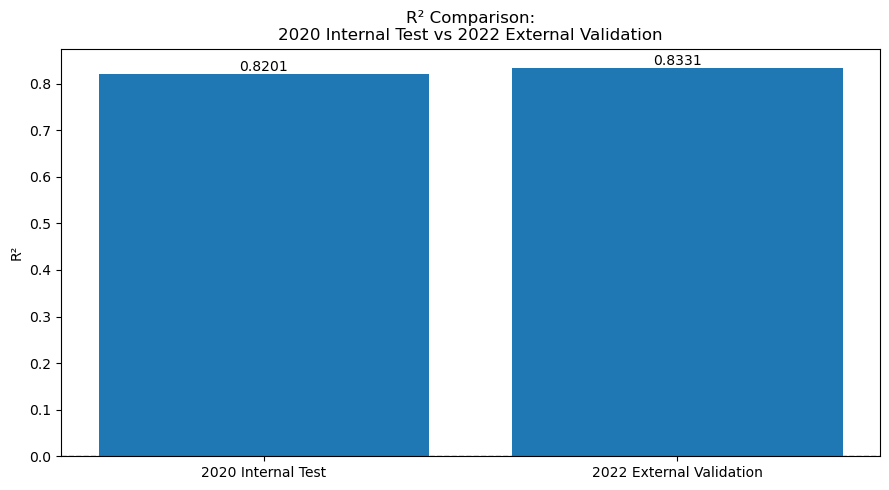

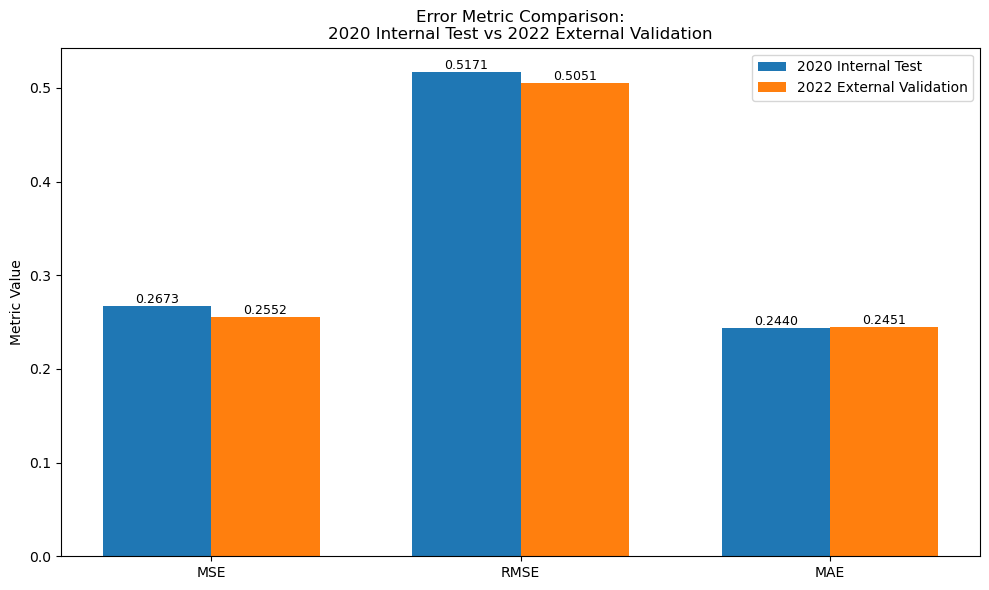


Comparison results saved successfully:

Main comparison:
C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\comparison_2020_internal_vs_2022_external.csv

Performance changes:
C:\Users\leeji\FYP2\CFPS\ML\2020_2.0\GB\performance_change_2020_vs_2022.csv


In [45]:
# ============================================================
# COMPARE 2020 INTERNAL TEST RESULTS VS 2022 EXTERNAL VALIDATION
# LOG1P TARGET SCALE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CHECK REQUIRED METRIC OBJECTS
# ============================================================

required_objects = [
    "test_r2_clean",
    "test_mse_clean",
    "test_rmse_clean",
    "test_mae_clean",
    "external_r2_log",
    "external_mse_log",
    "external_rmse_log",
    "external_mae_log"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Some required metric variables are missing.\n"
        "Run the 2020 model evaluation and 2022 external "
        "validation cells first.\n\n"
        f"Missing variables: {missing_objects}"
    )

# ============================================================
# 2. OPTIONAL SAMPLE-SIZE INFORMATION
# ============================================================

# 2020 testing sample size
if "y_te_clean" in globals():
    sample_size_2020 = len(y_te_clean)

elif "y_test" in globals():
    sample_size_2020 = len(y_test)

else:
    sample_size_2020 = np.nan

# 2022 external-validation sample size
if "y_external" in globals():
    sample_size_2022 = len(y_external)

else:
    sample_size_2022 = np.nan

# ============================================================
# 3. CREATE COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(
    {
        "Dataset": [
            "2020 Internal Test",
            "2022 External Validation"
        ],
        "Validation_Type": [
            "Internal hold-out testing",
            "External temporal validation"
        ],
        "R2": [
            test_r2_clean,
            external_r2_log
        ],
        "MSE": [
            test_mse_clean,
            external_mse_log
        ],
        "RMSE": [
            test_rmse_clean,
            external_rmse_log
        ],
        "MAE": [
            test_mae_clean,
            external_mae_log
        ],
        "Observations": [
            sample_size_2020,
            sample_size_2022
        ]
    }
)

# ============================================================
# 4. CALCULATE ABSOLUTE PERFORMANCE DIFFERENCES
# ============================================================

r2_difference = external_r2_log - test_r2_clean
mse_difference = external_mse_log - test_mse_clean
rmse_difference = external_rmse_log - test_rmse_clean
mae_difference = external_mae_log - test_mae_clean

# ============================================================
# 5. CALCULATE PERCENTAGE CHANGE
# ============================================================
# For error metrics, a positive percentage means worse external
# performance because the error became larger.
#
# For R², the percentage change is shown only when the 2020
# R² is not zero.

if test_r2_clean != 0:
    r2_percentage_change = (
        r2_difference / abs(test_r2_clean)
    ) * 100
else:
    r2_percentage_change = np.nan

if test_mse_clean != 0:
    mse_percentage_change = (
        mse_difference / test_mse_clean
    ) * 100
else:
    mse_percentage_change = np.nan

if test_rmse_clean != 0:
    rmse_percentage_change = (
        rmse_difference / test_rmse_clean
    ) * 100
else:
    rmse_percentage_change = np.nan

if test_mae_clean != 0:
    mae_percentage_change = (
        mae_difference / test_mae_clean
    ) * 100
else:
    mae_percentage_change = np.nan

# ============================================================
# 6. CREATE PERFORMANCE-CHANGE TABLE
# ============================================================

difference_df = pd.DataFrame(
    {
        "Metric": [
            "R2",
            "MSE",
            "RMSE",
            "MAE"
        ],
        "2020_Internal_Test": [
            test_r2_clean,
            test_mse_clean,
            test_rmse_clean,
            test_mae_clean
        ],
        "2022_External_Validation": [
            external_r2_log,
            external_mse_log,
            external_rmse_log,
            external_mae_log
        ],
        "Absolute_Change_2022_minus_2020": [
            r2_difference,
            mse_difference,
            rmse_difference,
            mae_difference
        ],
        "Percentage_Change": [
            r2_percentage_change,
            mse_percentage_change,
            rmse_percentage_change,
            mae_percentage_change
        ]
    }
)

# ============================================================
# 7. ADD SIMPLE INTERPRETATION
# ============================================================

interpretations = []

# R² interpretation
if external_r2_log > test_r2_clean:
    interpretations.append(
        "R² improved during 2022 external validation."
    )
elif external_r2_log < test_r2_clean:
    interpretations.append(
        "R² decreased during 2022 external validation."
    )
else:
    interpretations.append(
        "R² remained unchanged."
    )

# RMSE interpretation
if external_rmse_log < test_rmse_clean:
    interpretations.append(
        "RMSE improved because the external-validation error "
        "was lower."
    )
elif external_rmse_log > test_rmse_clean:
    interpretations.append(
        "RMSE worsened because the external-validation error "
        "was higher."
    )
else:
    interpretations.append(
        "RMSE remained unchanged."
    )

# MAE interpretation
if external_mae_log < test_mae_clean:
    interpretations.append(
        "MAE improved because the average absolute error "
        "was lower."
    )
elif external_mae_log > test_mae_clean:
    interpretations.append(
        "MAE worsened because the average absolute error "
        "was higher."
    )
else:
    interpretations.append(
        "MAE remained unchanged."
    )

# ============================================================
# 8. DISPLAY THE MAIN COMPARISON
# ============================================================

print("\n" + "=" * 78)
print("       2020 INTERNAL TEST VS 2022 EXTERNAL VALIDATION")
print("                      LOG1P SCALE")
print("=" * 78)

print(
    f"{'Metric':<12}"
    f"{'2020 Internal Test':>24}"
    f"{'2022 External':>22}"
    f"{'Difference':>18}"
)

print("-" * 78)

print(
    f"{'R²':<12}"
    f"{test_r2_clean:>24.4f}"
    f"{external_r2_log:>22.4f}"
    f"{r2_difference:>18.4f}"
)

print(
    f"{'MSE':<12}"
    f"{test_mse_clean:>24.4f}"
    f"{external_mse_log:>22.4f}"
    f"{mse_difference:>18.4f}"
)

print(
    f"{'RMSE':<12}"
    f"{test_rmse_clean:>24.4f}"
    f"{external_rmse_log:>22.4f}"
    f"{rmse_difference:>18.4f}"
)

print(
    f"{'MAE':<12}"
    f"{test_mae_clean:>24.4f}"
    f"{external_mae_log:>22.4f}"
    f"{mae_difference:>18.4f}"
)

print("=" * 78)

print("\nSample sizes:")
print(f"2020 internal test observations : {sample_size_2020}")
print(f"2022 external observations      : {sample_size_2022}")

print("\nInterpretation:")

for statement in interpretations:
    print(f"- {statement}")

# ============================================================
# 9. DISPLAY COMPARISON DATAFRAME
# ============================================================

print("\n" + "=" * 78)
print("DETAILED COMPARISON TABLE")
print("=" * 78)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

print("\n" + "=" * 78)
print("PERFORMANCE CHANGE TABLE")
print("=" * 78)

print(
    difference_df.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

# ============================================================
# 10. PLOT R² COMPARISON
# ============================================================

r2_plot_df = comparison_df[
    ["Dataset", "R2"]
].copy()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    r2_plot_df["Dataset"],
    r2_plot_df["R2"]
)

plt.ylabel("R²")
plt.title(
    "R² Comparison:\n"
    "2020 Internal Test vs 2022 External Validation"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

for bar, value in zip(bars, r2_plot_df["R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ============================================================
# 11. PLOT ERROR-METRIC COMPARISON
# ============================================================

error_plot_df = pd.DataFrame(
    {
        "Metric": [
            "MSE",
            "RMSE",
            "MAE"
        ],
        "2020 Internal Test": [
            test_mse_clean,
            test_rmse_clean,
            test_mae_clean
        ],
        "2022 External Validation": [
            external_mse_log,
            external_rmse_log,
            external_mae_log
        ]
    }
)

x_positions = np.arange(
    len(error_plot_df["Metric"])
)

bar_width = 0.35

plt.figure(figsize=(10, 6))

bars_2020 = plt.bar(
    x_positions - bar_width / 2,
    error_plot_df["2020 Internal Test"],
    width=bar_width,
    label="2020 Internal Test"
)

bars_2022 = plt.bar(
    x_positions + bar_width / 2,
    error_plot_df["2022 External Validation"],
    width=bar_width,
    label="2022 External Validation"
)

plt.xticks(
    x_positions,
    error_plot_df["Metric"]
)

plt.ylabel("Metric Value")
plt.title(
    "Error Metric Comparison:\n"
    "2020 Internal Test vs 2022 External Validation"
)

plt.legend()

for bar in bars_2020:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars_2022:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ============================================================
# 12. SAVE RESULTS
# ============================================================

OUTPUT_FOLDER = os.getcwd()

if "DATA_2022_PATH" in globals():
    OUTPUT_FOLDER = os.path.dirname(
        os.path.abspath(DATA_2022_PATH)
    )

COMPARISON_OUTPUT_PATH = os.path.join(
    OUTPUT_FOLDER,
    "comparison_2020_internal_vs_2022_external.csv"
)

DIFFERENCE_OUTPUT_PATH = os.path.join(
    OUTPUT_FOLDER,
    "performance_change_2020_vs_2022.csv"
)

comparison_df.to_csv(
    COMPARISON_OUTPUT_PATH,
    index=False
)

difference_df.to_csv(
    DIFFERENCE_OUTPUT_PATH,
    index=False
)

print("\nComparison results saved successfully:")

print("\nMain comparison:")
print(COMPARISON_OUTPUT_PATH)

print("\nPerformance changes:")
print(DIFFERENCE_OUTPUT_PATH)